<a href="https://colab.research.google.com/github/lahiru-praveen/quantization-aware-machine-unlearning-slm/blob/develop/notebooks/12_visualize_all_layer_scores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 12: Aggregating and Visualizing All-Layer Recovery Scores

Notebook 10 gave me a causal tracing recovery score for every layer, for every article in my forget set, saved in `trace_map.json`. That's useful for looking at one fact at a time, but for my thesis I need to answer a bigger question: **across my whole forget set, which layers consistently matter most for storing facts?**

This notebook does two things:
1. A dropdown explorer so I can still spot-check individual articles.
2. Aggregates every article's 32-layer recovery scores into dataset-wide statistics (mean, std dev, median, and how often each layer appears in an article's "top 3"), and produces the final dashboard figure I'll use in my Results chapter.

**Input:** `trace_map.json` (from Notebook 10).
**Output:** `global_mechanistic_stats.csv` (summary table) and `global_mechanistic_analysis_profile.pdf` (the two-panel dashboard figure).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U plotly ipywidgets nbformat --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 146.6 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


## Interactive Saliency Map Explorer

Now that Notebook 10 has produced `trace_map.json` (the causal tracing results), I want a way to quickly browse through different articles and see which layers were most responsible for storing each fact - this is basically my first pass at the "saliency map" visualization I'll need for my thesis results chapter.

I can spot-check individual articles while working on the aggregate statistics below.

In [ ]:
import json
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# 1. Load the trace map
INPUT_JSON_PATH = "/content/drive/MyDrive/ResearchProject/trace_map.json"
# INPUT_JSON_PATH = "../data/processed/trace_map.json"
with open(INPUT_JSON_PATH, "r") as f:
    trace_map = json.load(f)

# 2. Prepare the dropdown options
dropdown_options = {}
for article_id, data in trace_map.items():
    snippet = data['text'][:50].replace('\n', ' ') + "..."
    label = f"Article {article_id} - {snippet}"
    dropdown_options[label] = article_id

output_area = widgets.Output()

DISPLAY_MIN, DISPLAY_MAX = -2.0, 2.0

def plot_saliency_map(selected_article_id):
    output_area.clear_output(wait=True)

    data = trace_map[selected_article_id]
    raw_scores = np.array(data['all_layer_scores'])
    n_layers = len(raw_scores)

    # Rank top-3 using the RAW scores, so clipping doesn't change which layers count as "important"
    top_2_layers = sorted(range(n_layers), key=lambda i: raw_scores[i], reverse=True)[:2]

    # Clip only what gets DRAWN, so one extreme layer can't squash the whole chart
    display_scores = np.clip(raw_scores, DISPLAY_MIN, DISPLAY_MAX)
    is_outlier = (raw_scores < DISPLAY_MIN) | (raw_scores > DISPLAY_MAX)

    # Purple = value was clipped for display, Red = top-3 layer, Blue = normal layer
    marker_colors = []
    for idx in range(n_layers):
        if is_outlier[idx]:
            marker_colors.append('#a855f7')
        elif idx in top_2_layers:
            marker_colors.append('#ef4444')
        else:
            marker_colors.append('#3b82f6')

    fig = go.Figure(data=[
        go.Bar(
            x=list(range(n_layers)),
            y=display_scores,
            marker_color=marker_colors,
            name="Recovery Score",
            customdata=raw_scores,
            hovertemplate="Layer %{x}<br>Displayed: %{y:.3f}<br>Actual raw score: %{customdata:.3f}<extra></extra>"
        )
    ])
    fig.update_layout(
        title=f"Mechanistic Localization for Article {selected_article_id}",
        xaxis_title="Transformer Layer",
        yaxis_title="Recovery of Target Fact (clipped to [-2, 2] for display)",
        yaxis=dict(range=[DISPLAY_MIN - 0.2, DISPLAY_MAX + 0.2]),  # fixed range, not autorange
        template="plotly_white",
        height=500,
        margin=dict(l=40, r=40, t=60, b=40)
    )

    with output_area:
        print(f"Top 3 Identified Layers (based on raw, unclipped scores): {top_2_layers}")
        print(f"Original Saved Layers: {data['top_layers']}\n")
        if is_outlier.any():
            outlier_layers = [i for i in range(n_layers) if is_outlier[i]]
            print(f"⚠️ Layers with extreme raw scores, clipped for display (shown in purple):")
            for i in outlier_layers:
                print(f"    Layer {i}: raw score = {raw_scores[i]:.3f}")
            print()
        print(f"Target Text Snippet:\n{data['text'][:250]}...\n")

        # fig.show() OUTSIDE the widget Output — this is the earlier nesting fix, still needed
        fig.show()

article_dropdown = widgets.Dropdown(options=dropdown_options, description='Select Data:', layout={'width': '80%'})

def on_dropdown_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        plot_saliency_map(change['new'])

article_dropdown.observe(on_dropdown_change)

print("--- Interactive Saliency Map Explorer ---")
display(article_dropdown, output_area)

initial_key = list(dropdown_options.values())[0]
plot_saliency_map(initial_key)

--- Interactive Saliency Map Explorer ---


Dropdown(description='Select Data:', layout=Layout(width='80%'), options={'Article 0 - Greek Prime Minister Ky…

Output()

## Aggregating Recovery Scores Across the Whole Forget Set

Here I loop over every article in `trace_map.json` and stack all their 32-layer recovery scores into one big matrix (rows = articles, columns = layers). From this matrix I compute, per layer:

- the mean recovery score,
- the standard deviation,
- the median recovery score,
- and how many times that layer appeared in an article's top-3 most important layers.

The idea is that if a layer consistently shows up with high recovery scores and appears often in the top-3 across hundreds of articles, that's good evidence it's a genuinely important layer for storing factual knowledge in this model, not just a one-off result for a single fact.


In [ ]:
import json
import pandas as pd
import numpy as np

# 1. Load the master trace map
with open(INPUT_JSON_PATH, "r") as f:
    trace_map = json.load(f)

# 2. Initialize arrays to collect aggregate statistics
all_scores_matrix = []
top_2_layer_counts = np.zeros(32) # Phi-3-mini-4k-instruct has 32 transformer layers

# We cap scores to [-2.0, 2.0] to prevent exploding denominators from destroying the mean
LOWER_BOUND = -2.0
UPPER_BOUND = 2.0

# 3. Process every single data point
for article_id, data in trace_map.items():
    raw_scores = data['all_layer_scores']

    # Convert to numpy array for easy element-wise operations
    scores = np.array(raw_scores)
    scores = np.clip(scores, LOWER_BOUND, UPPER_BOUND)

    all_scores_matrix.append(scores.tolist())

    # Dynamically extract the top 3 layers based on the *capped* scores
    top_2_layers = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:2]

    # Increment counts for these layers
    for layer in top_2_layers:
        if layer < 32:
            top_2_layer_counts[layer] += 1

# 4. Convert matrix to a NumPy array for easy statistical manipulation
all_scores_matrix = np.array(all_scores_matrix)

# 5. Compute global macro statistics per layer
mean_scores = np.mean(all_scores_matrix, axis=0)
std_scores = np.std(all_scores_matrix, axis=0)
median_scores = np.median(all_scores_matrix, axis=0)

# 6. Create a clean Summary DataFrame for thesis reporting
summary_df = pd.DataFrame({
    'Layer': list(range(32)),
    'Global_Mean_Recovery': mean_scores,
    'Global_Std_Dev': std_scores,
    'Global_Median_Recovery': median_scores,
    'Top_2_Appearance_Frequency': top_2_layer_counts.astype(int)
})

# Save stats to a CSV for your thesis appendix
# OUTPUT_CSV_PATH = "../data/processed/global_mechanistic_stats.csv"
OUTPUT_CSV_PATH = "/content/drive/MyDrive/ResearchProject/global_mechanistic_stats.csv"
summary_df.to_csv(OUTPUT_CSV_PATH, index=False)

print("✅ Global statistical data aggregated successfully and saved to CSV!")
print("\nTop 5 Layers by global Top-3 appearance frequency:")
print(summary_df.sort_values(by='Top_2_Appearance_Frequency', ascending=False).head(5).to_string(index=False))

✅ Global statistical data aggregated successfully and saved to CSV!

Top 5 Layers by global Top-3 appearance frequency:
 Layer  Global_Mean_Recovery  Global_Std_Dev  Global_Median_Recovery  Top_2_Appearance_Frequency
     0              0.210793        1.275451                0.171935                         347
     1              0.177366        1.192911                0.110859                         292
     2              0.105237        1.385379                0.060762                         175
    31              0.137383        0.976643                0.053776                          93
     6              0.124327        1.098927                0.042196                          85


## Final Dashboard Figure for Thesis

This is the two-panel figure I'll use in my Results chapter to show where knowledge tends to be localized across the whole forget set:

- **Panel A** shows, for each layer, how many times it appeared in an article's top-3 most important layers. Taller bars mean that layer is more consistently important across many different facts, not just a few.
- **Panel B** shows the mean recovery score per layer as a line, with a shaded band showing ±1 standard deviation, giving a sense of both the typical recovery pattern and how much it varies across articles.

I'm using matplotlib + seaborn here instead of Plotly, specifically because I need a static image that actually gets saved into my PDF and doesn't depend on a live kernel or a specific renderer — this is the version that's actually safe to put in my thesis.

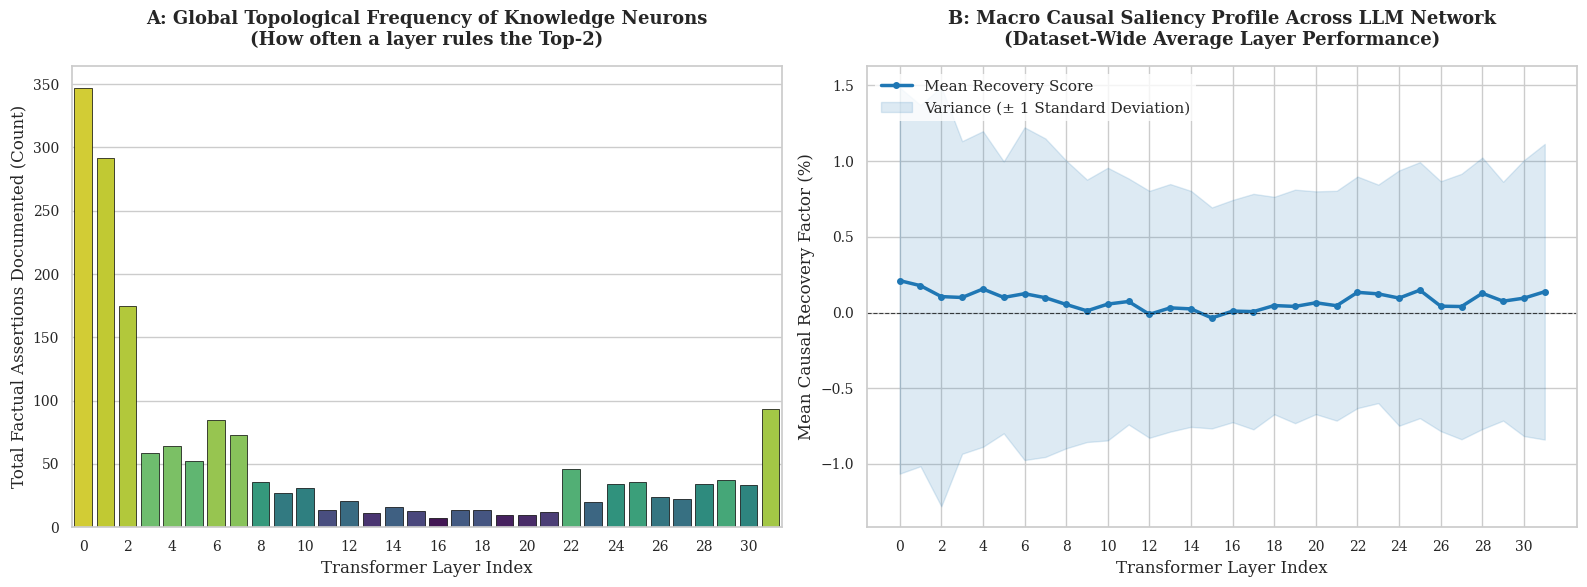

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15
})

# Create a 1-row, 2-column dashboard layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PANEL A: Global Top-2 Layer Frequency Distribution

colors = sns.color_palette("viridis", len(summary_df))
# Rank color intensity by frequency
rank = summary_df['Top_2_Appearance_Frequency'].argsort().argsort()
palette = [colors[r] for r in rank]

sns.barplot(
       x='Layer',
       y='Top_2_Appearance_Frequency',
       data=summary_df,
       hue='Layer',
       palette=palette,
       legend=False,
       ax=ax1,
       edgecolor='black',
       linewidth=0.5
   )
ax1.set_title("A: Global Topological Frequency of Knowledge Neurons\n(How often a layer rules the Top-2)", pad=15, fontweight='bold')
ax1.set_xlabel("Transformer Layer Index")
ax1.set_ylabel("Total Factual Assertions Documented (Count)")
ax1.set_xticks(range(0, 32, 2)) # Keep x-axis readable

# PANEL B: Macro Layer-Impact Profile (Mean ± Std Dev)
# Plot the mean recovery trend line
ax2.plot(
    summary_df['Layer'],
    summary_df['Global_Mean_Recovery'],
    color='#1f77b4',
    linewidth=2.5,
    label='Mean Recovery Score',
    marker='o',
    markersize=4
)

# Overlay the standard deviation as a shaded confidence band
ax2.fill_between(
    summary_df['Layer'],
    summary_df['Global_Mean_Recovery'] - summary_df['Global_Std_Dev'],
    summary_df['Global_Mean_Recovery'] + summary_df['Global_Std_Dev'],
    color='#1f77b4',
    alpha=0.15,
    label='Variance (± 1 Standard Deviation)'
)

ax2.set_title("B: Macro Causal Saliency Profile Across LLM Network\n(Dataset-Wide Average Layer Performance)", pad=15, fontweight='bold')
ax2.set_xlabel("Transformer Layer Index")
ax2.set_ylabel("Mean Causal Recovery Factor (%)")
ax2.set_xticks(range(0, 32, 2))
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7) # Zero line index boundary
ax2.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# Optimize layout and boundaries
plt.tight_layout()

# Save the high-resolution vector image directly for your thesis PDF file
# OUTPUT_CSV_PATH = "../reports/figures/global_mechanistic_analysis_profile.png"
OUTPUT_CSV_PATH = "/content/drive/MyDrive/ResearchProject/global_mechanistic_analysis_profile.pdf"
plt.savefig(OUTPUT_CSV_PATH, dpi=300, bbox_inches='tight')

plt.show()